# Tugas 1 - Klasifikasi Jamur dengan Naive Bayes

| Nama | NRP |
|------|-----|
| Rayhan Lutfi Hakim | 5054251043|

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Mushroom Dataset dari UCI Machine Learning Repository.

Dataset dapat diakses melalui:
- https://www.kaggle.com/datasets/uciml/mushroom-classification

Untuk metadata / penjelasan mengenai dataset bisa mengakses link berikut:
- https://archive.ics.uci.edu/dataset/73/mushroom

Tujuan utama dari tugas ini adalah membangun dan membandingkan tiga varian Naive Bayes, yaitu Categorical NB, Bernoulli NB, dan Multinomial NB, untuk mengklasifikasikan apakah suatu jamur dapat dimakan (edible) atau beracun (poisonous).

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan untuk masing-masing varian Naive Bayes.
3. Eksperimen Model
   - Bangun model Categorical NB, Bernoulli NB, dan Multinomial NB.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil ketiga model dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [1]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import CategoricalNB, BernoulliNB, MultinomialNB
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

In [2]:
# Load dataset dan tampilkan beberapa baris pertama.
# Semua nilai pada dataset berupa single character yang merupakan kode singkatan dari kategori.
# Contoh: pada kolom class, e = edible dan p = poisonous.
df = pd.read_csv("D:\ML\mushrooms.csv")
df.head()

<>:4: SyntaxWarning: invalid escape sequence '\M'
<>:4: SyntaxWarning: invalid escape sequence '\M'
C:\Users\M S I\AppData\Local\Temp\ipykernel_20656\3815916704.py:4: SyntaxWarning: invalid escape sequence '\M'
  df = pd.read_csv("D:\ML\mushrooms.csv")


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [3]:
# Tampilkan informasi dasar dataset: jumlah baris dan kolom, tipe data, dan jumlah missing value.
# Perhatikan kolom stalk-root yang memiliki nilai '?' sebagai representasi missing value.
df.info()
print("data duplikat: ", df.duplicated().sum())
print("Jumlah baris dan kolom:", df.shape)
print("\nTipe data:", df.dtypes)
print("\nJumlah missing value:", df.isnull().sum())


<class 'pandas.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   class                     8124 non-null   str  
 1   cap-shape                 8124 non-null   str  
 2   cap-surface               8124 non-null   str  
 3   cap-color                 8124 non-null   str  
 4   bruises                   8124 non-null   str  
 5   odor                      8124 non-null   str  
 6   gill-attachment           8124 non-null   str  
 7   gill-spacing              8124 non-null   str  
 8   gill-size                 8124 non-null   str  
 9   gill-color                8124 non-null   str  
 10  stalk-shape               8124 non-null   str  
 11  stalk-root                8124 non-null   str  
 12  stalk-surface-above-ring  8124 non-null   str  
 13  stalk-surface-below-ring  8124 non-null   str  
 14  stalk-color-above-ring    8124 non-null   str  
 15

In [4]:
# Tampilkan jumlah nilai unik pada setiap fitur.
# Perhatikan variasi jumlah kategori antar fitur, misalnya veil-type hanya punya 1 nilai unik.
for x in (df.columns):
    print(f"{x} : {df[x].nunique()}")

class : 2
cap-shape : 6
cap-surface : 4
cap-color : 10
bruises : 2
odor : 9
gill-attachment : 2
gill-spacing : 2
gill-size : 2
gill-color : 12
stalk-shape : 2
stalk-root : 5
stalk-surface-above-ring : 4
stalk-surface-below-ring : 4
stalk-color-above-ring : 9
stalk-color-below-ring : 9
veil-type : 1
veil-color : 4
ring-number : 3
ring-type : 5
spore-print-color : 9
population : 6
habitat : 7


Jumlah sampel per kelas:
 class
e    4208
p    3916
Name: count, dtype: int64


C:\Users\M S I\AppData\Local\Temp\ipykernel_20656\2876783248.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='class', data=df, palette='viridis')


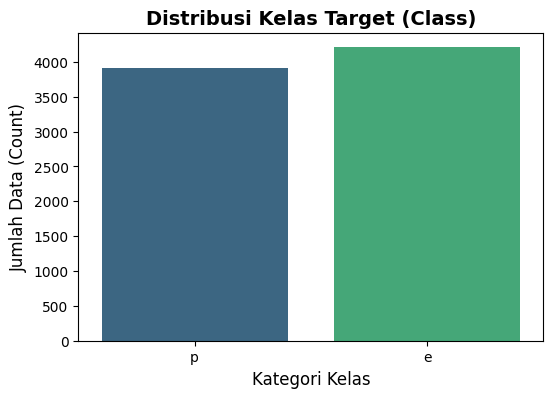

In [ ]:
# Tampilkan distribusi kelas target (class) dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
target_counts = df['class'].value_counts()
print("Jumlah sampel per kelas:\n", target_counts)

# 2. Membuat Bar Plot menggunakan Seaborn
plt.figure(figsize=(6, 4))
sns.countplot(x='class', data=df, palette='viridis')

# 3. Menambahkan Judul dan Label agar grafik informatif
plt.title('Distribusi Kelas Target (Class)', fontsize=14, fontweight='bold')
plt.xlabel('Kategori Kelas', fontsize=12)
plt.ylabel('Jumlah Data (Count)', fontsize=12)

# 4. Menampilkan Grafik
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

# 2. Preprocessing

Karena semua fitur bertipe kategorikal, setiap varian Naive Bayes membutuhkan representasi data yang berbeda:

| Model | Representasi yang dibutuhkan | Preprocessing |
|---|---|---|
| Categorical NB | Integer per kategori | OrdinalEncoder |
| Bernoulli NB | Binary 0/1 per kategori | LabelBinarizer / OneHotEncoder |
| Multinomial NB | Count / frekuensi non-negatif | OneHotEncoder |

In [ ]:
# Tangani missing value pada kolom stalk-root (nilai '?').
# Pilih strategi yang sesuai: drop baris, ganti dengan modus, atau jadikan kategori tersendiri.
df['stalk-root'] = df['stalk-root'].replace('?', 'unknown')

In [ ]:
# Periksa apakah ada fitur yang hanya memiliki satu nilai unik.
# Fitur seperti itu tidak memberikan informasi apapun dan sebaiknya di-drop.
df_clean = df.dropna(subset=['veil-type'])

In [ ]:
# Pisahkan fitur (X) dan target (y).
# Encode target: e = 0 (edible), p = 1 (poisonous).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.
X = df.drop(columns=['class'])
y = df['class']

# 2. Encode target: e = 0 (edible), p = 1 (poisonous)
y = y.map({'e': 0, 'p': 1})

# 3. Bagi data menjadi train set dan test set (80:20) dengan stratify=y
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    random_state=42,  # Agar hasil pembagian konsisten saat di-run ulang
    stratify=y        # Menjaga distribusi kelas e dan p tetap proporsional
)

# Optional: Cek dimensi hasil pembagian
print(f"Jumlah data X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Jumlah data X_test: {X_test.shape}, y_test: {y_test.shape}")

Jumlah data X_train: (6499, 22), y_train: (6499,)
Jumlah data X_test: (1625, 22), y_test: (1625,)


In [ ]:
# Preprocessing untuk Categorical NB:
# Gunakan OrdinalEncoder untuk mengubah setiap kategori menjadi integer.
# Contoh: cap-shape b=0, c=1, f=2, k=3, s=4, x=5
# Fit hanya pada train set, transform pada train set dan test set.

ordinal_encoder = OrdinalEncoder()

ordinal_encoder.fit(X_train)

# Transform ke train set dan test set
X_train_encoded = ordinal_encoder.transform(X_train)
X_test_encoded  = ordinal_encoder.transform(X_test)

In [ ]:
# Preprocessing untuk Bernoulli NB dan Multinomial NB:
# Gunakan OneHotEncoder untuk mengubah setiap kategori menjadi representasi binary.
# Hasilnya berupa matriks sparse dengan nilai 0 dan 1.
# Fit hanya pada train set, transform pada train set dan test set.

onehot_encoder = OneHotEncoder(sparse_output=True)
onehot_encoder.fit(X_train)

X_train_onehot = onehot_encoder.transform(X_train)
X_test_onehot  = onehot_encoder.transform(X_test)

# 3. Eksperimen Model

## 3.1 Categorical Naive Bayes

CategoricalNB adalah varian yang paling sesuai untuk dataset ini karena semua fitur memang bertipe kategorikal. Model menghitung P(fitur=kategori | kelas) secara langsung untuk setiap kategori pada setiap fitur.

In [ ]:
# Inisialisasi dan latih model CategoricalNB menggunakan train set hasil OrdinalEncoder.
cnb = CategoricalNB()
cnb.fit(X_train_encoded, y_train)

,"alpha alpha: float, default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"min_categories min_categories: int or array-like of shape (n_features,), default=NoneMinimum number of categories per feature.- integer: Sets the minimum number of categories per feature to `n_categories` for each features.- array-like: shape (n_features,) where `n_categories[i]` holds the minimum number of categories for the ith column of the input.- None (default): Determines the number of categories automatically from the training data... versionadded:: 0.24",None


In [ ]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.

y_pred_cnb = cnb.predict(X_test_encoded)

# Simpan probabilitas kelas 1 (poisonous)
y_proba_cnb = cnb.predict_proba(X_test_encoded)[:, 1]

## 3.2 Bernoulli Naive Bayes

BernoulliNB bekerja pada representasi binary. Dengan OneHotEncoder, setiap kategori menjadi kolom tersendiri bernilai 0 atau 1, sehingga model memperlakukan setiap kategori sebagai fitur binary ada/tidak ada.

In [15]:
# Inisialisasi dan latih model BernoulliNB menggunakan train set hasil OneHotEncoder.
bnb = BernoulliNB()
bnb.fit(X_train_onehot, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"binarize binarize: float or None, default=0.0Threshold for binarizing (mapping to booleans) of sample features.If None, input is presumed to already consist of binary vectors.",0.0
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [16]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_bnb = bnb.predict(X_test_onehot)

# Simpan probabilitas kelas 1 (poisonous)
y_proba_bnb = bnb.predict_proba(X_test_onehot)[:, 1]

## 3.3 Multinomial Naive Bayes

MultinomialNB membutuhkan input non-negatif dan menginterpretasikannya sebagai frekuensi. Dengan OneHotEncoder yang menghasilkan nilai 0 dan 1, model dapat menerimanya sebagai counts meskipun secara semantik tiap nilai hanya menandakan ada/tidak ada kategori.

In [ ]:
# Inisialisasi dan latih model MultinomialNB menggunakan train set hasil OneHotEncoder.
mnb = MultinomialNB()
mnb.fit(X_train_onehot, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [ ]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_mnb = mnb.predict(X_test_onehot)

# Simpan probabilitas kelas 1 (poisonous)
y_proba_mnb = mnb.predict_proba(X_test_onehot)[:, 1]

# 4. Evaluasi Model

In [ ]:
# Tampilkan metrik evaluasi untuk setiap model: Accuracy, Precision, Recall, dan F1-Score.
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.
models_pred = {
    'Categorical NB': y_pred_cnb,
    'Bernoulli NB'  : y_pred_bnb,
    'Multinomial NB': y_pred_mnb,
}

metrics_list = []
for model_name, y_pred in models_pred.items():
    metrics_list.append({
        'Model'    : model_name,
        'Accuracy' : accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall'   : recall_score(y_test, y_pred),
        'F1-Score' : f1_score(y_test, y_pred),
    })

df_metrics = pd.DataFrame(metrics_list)
df_metrics = df_metrics.round(4)
display(df_metrics)

,Model,Accuracy,Precision,Recall,F1-Score
0,Categorical NB,0.9458,0.9901,0.8966,0.9410
1,Bernoulli NB,0.9329,0.9814,0.8774,0.9265
2,Multinomial NB,0.9458,0.9901,0.8966,0.9410


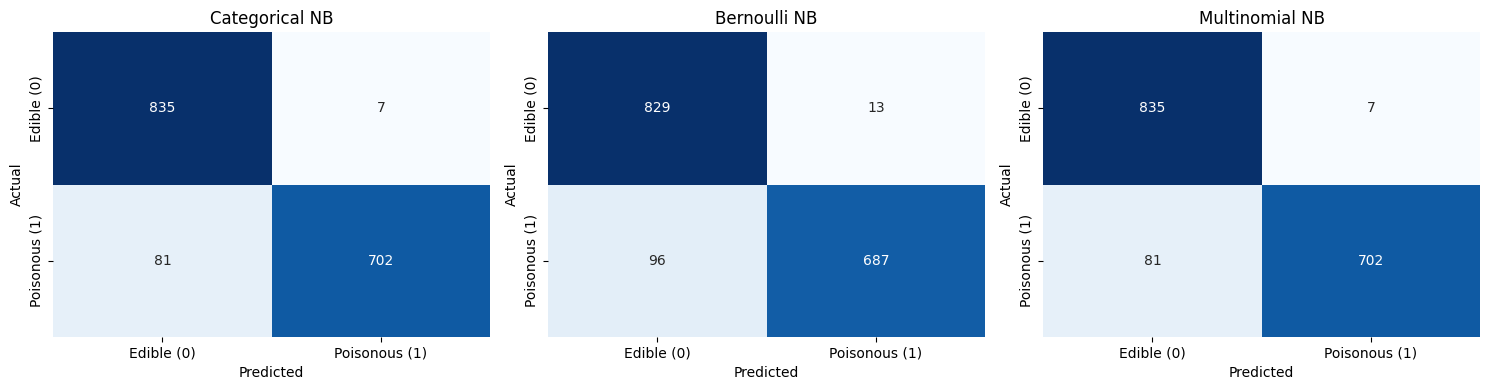

In [ ]:
# Tampilkan Confusion Matrix setiap model dalam bentuk heatmap.
# Susun ketiganya dalam satu baris subplot.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (model_name, y_pred) in zip(axes, models_pred.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Edible (0)', 'Poisonous (1)'],
                yticklabels=['Edible (0)', 'Poisonous (1)'])
    ax.set_title(model_name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

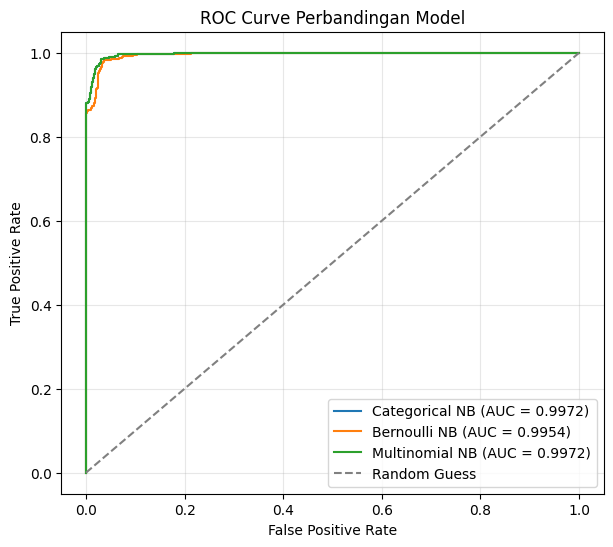

In [ ]:
# Tampilkan ROC Curve ketiga model dalam satu plot beserta nilai AUC masing-masing.
models_proba = {
    'Categorical NB': y_proba_cnb,
    'Bernoulli NB'  : y_proba_bnb,
    'Multinomial NB': y_proba_mnb,
}

plt.figure(figsize=(7, 6))

for model_name, y_proba in models_proba.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_score = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc_score:.4f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Perbandingan Model')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 5. Analisis

#### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan. Bandingkan performa Categorical NB, Bernoulli NB, dan Multinomial NB berdasarkan hasil evaluasi. Kaitkan perbedaan performa dengan perbedaan representasi data yang digunakan oleh masing-masing model. Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan.

CategoricalNB dan MultinomialNB memiliki yang benar benar sama dari segala hasil training, hal itu terjadi karena parameters yang digunakan juga sama. Sedangkan pada BernoulliNB memiliki tambahan parameter yaitu binarize, sehingga mendapat hasil yang berbeda dari keduanya.

# 6. Kesimpulan dan Saran

#### Berikan kesimpulan dari eksperimen yang telah dilakukan. Saran dapat berupa rekomendasi untuk eksperimen selanjutnya, perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

Melihat hasil training data metode CategoricalNB sebenarnya menjadi yang paling cocok karena semua tipe data di sini bersifat kategorikal. Namun ternyata MultinomialNB juga menghasilkan hasil training yang sama persis dengan CatergoricalNB.

Saran:
1. Mencoba model lainnya mengingat akurasi yang di dapat sangat tinggi sehingga ada resiko terjadinya overfitting (model menghafal data)